In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install kaggle 


Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
folders =[
    "data/raw",
    "data/processed",
    "notebooks",
    "src",
    "reports",
    "figures",
    "models"
]
for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

    Path("README.md").touch()
    Path("requirements.txt").touch()
    Path(".gitignore").touch()


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib as path

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [6]:
DATA_DIR=Path("../data/raw")
DATA_DIR.exists()
for file in DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [9]:
customers=pd.read_csv(DATA_DIR/"olist_customers_dataset.csv")
geolocation=pd.read_csv(DATA_DIR/"olist_geolocation_dataset.csv")
orders=pd.read_csv(DATA_DIR/"olist_orders_dataset.csv")
order_item=pd.read_csv(DATA_DIR/"olist_order_items_dataset.csv")
order_payments=pd.read_csv(DATA_DIR/"olist_order_payments_dataset.csv")
order_reviews=pd.read_csv(DATA_DIR/"olist_order_reviews_dataset.csv")
products=pd.read_csv(DATA_DIR/"olist_products_dataset.csv")
sellers=pd.read_csv(DATA_DIR/"olist_sellers_dataset.csv")
category_name_translation=pd.read_csv(DATA_DIR/"product_category_name_translation.csv")

tables={
    "customers":customers,
    "geolocation":geolocation,
    "order_item":order_item,
    "order_payments":order_payments,
    "order_reviews":order_reviews,
    "products":products,
    "sellers":sellers,
    "category_name_translation":category_name_translation,
    
}

In [10]:
for name,df in tables.items():
    print(f"{name}:{df.shape[0]}rows,{df.shape[1]}columns")
    customers.head()
    orders.head()
    order_item.head()
    products.head()

customers:99441rows,5columns
geolocation:1000163rows,5columns
order_item:112650rows,7columns
order_payments:103886rows,5columns
order_reviews:99224rows,7columns
products:32951rows,9columns
sellers:3095rows,4columns
category_name_translation:71rows,2columns


In [11]:
customers.info()
for name,df in tables.items():
    print("\n"+ "="*80)
    print(name.upper())
    print("="*80)
    print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes:

In [20]:
def summarize_table(name,df):
    return{
        "tables_name":name,
        "rows":df.shape[0],
        "columns":df.shape[1],
        "missing_values":df.isnull(). sum(). sum(),
        "duplicate_rows":df.duplicated(). sum(),
    }

summary=pd.DataFrame([
    summarize_table(name,df)
    for name , df in tables.items()
])

summary

summary.to_csv(r"C:\Users\DELL\ai-ninja-projects\machine learning 2026\reports\lab01_dataset_summary.csv", index=False)

In [ ]:
def missing_value_summary(df): 
    missing_count = df.isnull().sum() 
    missing_percent = (missing_count / len(df)) * 100
    result = pd.DataFrame({
         "missing_count": missing_count, 
        "missing_percent": missing_percent 
       })
    return result[result["missing_count"] > 0].sort_values(
         by="missing_percent",
         ascending=False
         )

missing_value_summary(orders)

for name ,df in tables.items():
    print("\n"+"="*80)
    print(f"Missing values in {name}")
    print("="* 80)
display(missing_value_summary(df))


Missing values in customers

Missing values in geolocation

Missing values in order_item

Missing values in order_payments

Missing values in order_reviews

Missing values in products

Missing values in sellers

Missing values in category_name_translation


,missing_count,missing_percent


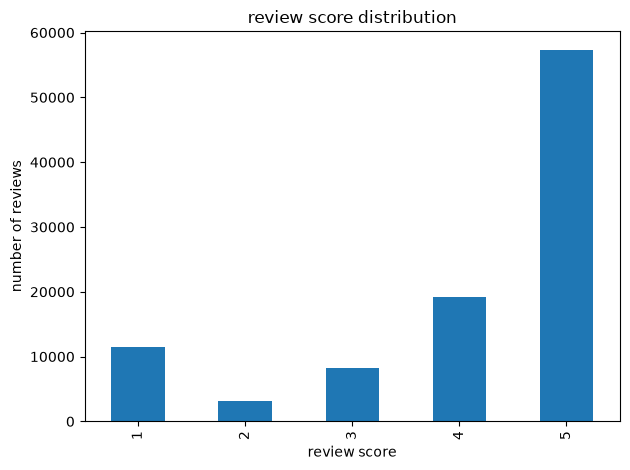

In [ ]:
order_reviews.head()
order_reviews["review_score"].value_counts().sort_index()
order_reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("review score distribution")
plt.ylabel("number of reviews")
plt.xlabel("review score")
plt.tight_layout()
plt.show()

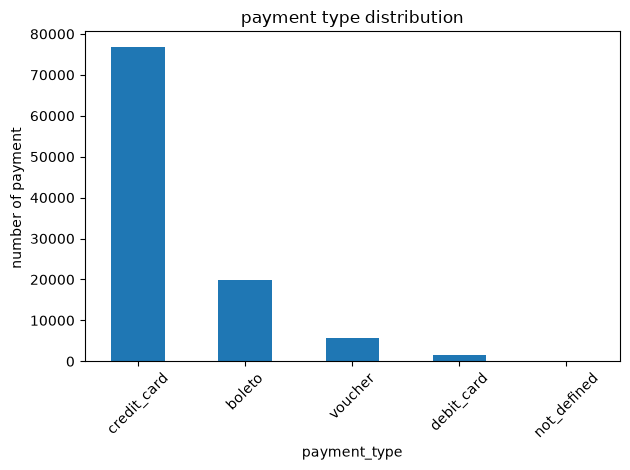

In [29]:
order_payments.head()
order_payments["payment_type"].value_counts()
order_payments["payment_type"].value_counts().plot(kind="bar")
plt.title("payment type distribution")
plt.ylabel("number of payment ")
plt.xlabel("payment_type")
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

In [34]:
products.head()
missing_value_summary(products)
products["product_category_name"].nunique()
products["product_category_name"].value_counts().head(10)


product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

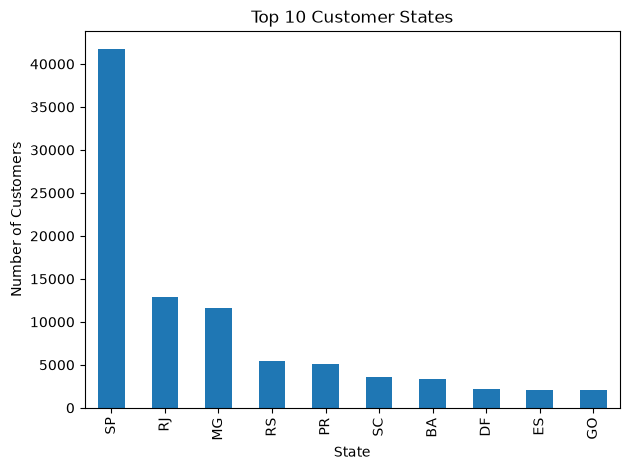

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [ ]:
customers.head()
customers["customer_state"].value_counts().head()
customers["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States") 
plt.xlabel("State") 
plt.ylabel("Number of Customers") 
plt.tight_layout() 
plt.show()
# print(customers.columns.tolist())

In [40]:
customers["customer_unique_id"].nunique()
orders["order_id"].nunique()
orders["order_status"].value_counts()
order_payments["payment_type"].value_counts()
order_reviews["review_score"].mean()
customers["customer_state"].value_counts().head(10)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [50]:
# brazilian_exports={}

# 1. Sample dictionary containing two DataFrames
brazilian_exports = pd.merge(
    customers, 
    orders, 
    on='customer_id', 
    how='left'  # 'left' keeps all customers, even if they haven't ordered yet
)

# Step 2: Connect that result to the individual order items
# This adds the specific products, quantities, and prices to those orders
final_master_df = pd.merge(
    brazilian_exports, 
    order_item, 
    on='order_id', 
    how='left'  # 'left' ensures we don't accidentally drop empty orders
)

# Step 3 (Optional): Save the final master table into your dictionary
my_data_dict = {
    'master_sales_sheet': final_master_df
}

print(my_data_dict)

{'master_sales_sheet':                              customer_id                customer_unique_id  \
0       06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1       18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2       4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3       b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4       4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                  ...                               ...   
113420  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
113421  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
113422  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
113423  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
113424  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

        customer_zip_code_prefix        